Poissonov problem $\\$
$-u''(x) = f(x)$ na $(0,1)$ $\\$
$u(0)=u(1)=0$

In [20]:
from netgen.meshing import Mesh as NGMesh, MeshPoint, Element1D, Element0D, Pnt
from ngsolve import *

import scipy.sparse as sp
from scipy.sparse import csr_matrix
import matplotlib.pylab as plt
import numpy as np

In [21]:
unit_interval = NGMesh(dim=1)

N = 40
pnums = []

for i in range(N+1):
    xc = i / N
    pnums.append(unit_interval.Add(MeshPoint(Pnt(xc, 0, 0))))

# 1D domain region
idx_dom = unit_interval.AddRegion("omega", dim=1)
for i in range(N):
    unit_interval.Add(Element1D([pnums[i], pnums[i+1]], index=idx_dom))

# 0D boundary regions
idx_left  = unit_interval.AddRegion("left", dim=0)
idx_right = unit_interval.AddRegion("right", dim=0)

unit_interval.Add(Element0D(pnums[0],  index=idx_left))
unit_interval.Add(Element0D(pnums[-1], index=idx_right))

mesh = Mesh(unit_interval)

In [22]:
print("dim =", mesh.dim)
print("vertices =", mesh.nv)
print("elements =", mesh.ne)
print("boundaries =", mesh.GetBoundaries())
print("materials =", mesh.GetMaterials())

dim = 1
vertices = 41
elements = 40
boundaries = ('left', 'right')
materials = ('omega',)


In [23]:
fes = H1(mesh, order=1, dirichlet="left|right")

In [24]:
print ("ndof =", fes.ndof)

ndof = 41


In [25]:
u = fes.TrialFunction()
v = fes.TestFunction()

f = LinearForm(fes)
f += x*(1-x)*v*dx

a = BilinearForm(fes)
a += InnerProduct(grad(u), grad(v)) * dx

a.Assemble()
f.Assemble()

In [26]:
n = a.mat.height
density = a.mat.nze / (n*n)
print("Ukupan broj elemenata:", n*n)
print("Broj nenul elemenata:", a.mat.nze)
print("Popunjenost:", density)

Ukupan broj elemenata: 1681
Broj nenul elemenata: 121
Popunjenost: 0.07198096371207614


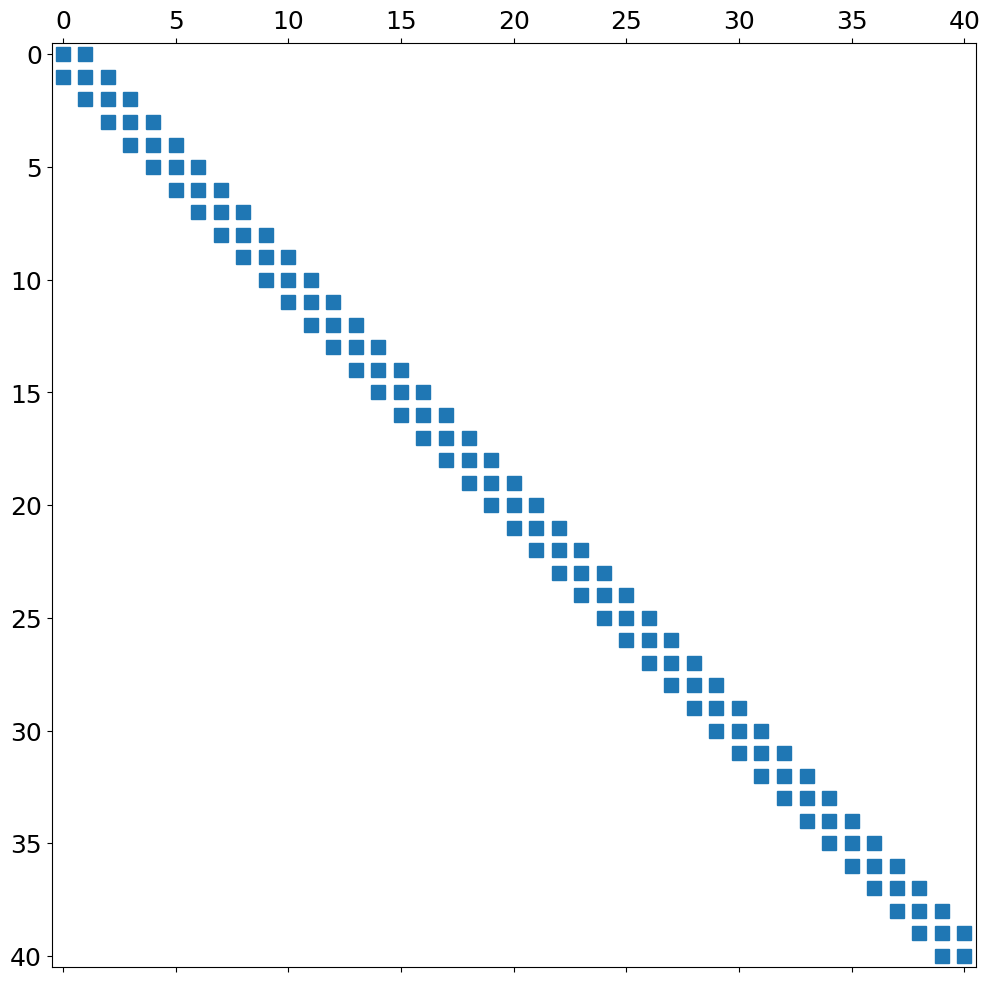

In [27]:
plt.rcParams['figure.figsize'] = (12, 12)
A = sp.csr_matrix(a.mat.CSR())

plt.spy(A)
plt.show()

In [28]:
print (csr_matrix(a.mat.CSR()))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 121 stored elements and shape (41, 41)>
  Coords	Values
  (0, 0)	40.0
  (0, 1)	-40.0
  (1, 0)	-40.0
  (1, 1)	80.0
  (1, 2)	-40.0
  (2, 1)	-40.0
  (2, 2)	80.0
  (2, 3)	-40.00000000000001
  (3, 2)	-40.00000000000001
  (3, 3)	80.0
  (3, 4)	-39.999999999999986
  (4, 3)	-39.999999999999986
  (4, 4)	80.0
  (4, 5)	-40.00000000000001
  (5, 4)	-40.00000000000001
  (5, 5)	80.00000000000001
  (5, 6)	-40.00000000000001
  (6, 5)	-40.00000000000001
  (6, 6)	80.00000000000001
  (6, 7)	-40.00000000000001
  (7, 6)	-40.00000000000001
  (7, 7)	79.99999999999997
  (7, 8)	-39.999999999999964
  (8, 7)	-39.999999999999964
  (8, 8)	79.99999999999997
  :	:
  (32, 32)	80.00000000000011
  (32, 33)	-40.00000000000014
  (33, 32)	-40.00000000000014
  (33, 33)	80.00000000000011
  (33, 34)	-39.999999999999964
  (34, 33)	-39.999999999999964
  (34, 34)	79.99999999999993
  (34, 35)	-39.999999999999964
  (35, 34)	-39.999999999999964
  (35, 35)	79.9999999999999

In [29]:
print (f.vec)

 0.000102865
 0.000606771
 0.0011849
 0.00173177
 0.0022474
 0.00273177
 0.0031849
 0.00360677
 0.0039974
 0.00435677
 0.0046849
 0.00498177
 0.0052474
 0.00548177
 0.0056849
 0.00585677
 0.0059974
 0.00610677
 0.0061849
 0.00623177
 0.0062474
 0.00623177
 0.0061849
 0.00610677
 0.0059974
 0.00585677
 0.0056849
 0.00548177
 0.0052474
 0.00498177
 0.0046849
 0.00435677
 0.0039974
 0.00360677
 0.0031849
 0.00273177
 0.0022474
 0.00173177
 0.0011849
 0.000606771
 0.000102865




In [30]:
solution_gf = GridFunction(fes)
solution_gf.vec.data = a.mat.Inverse(fes.FreeDofs()) * f.vec

In [31]:
print(solution_gf.vec)

       0
 0.00208076
 0.00414635
 0.00618232
 0.008175
 0.0101115
 0.0119797
 0.0137683
 0.0154667
 0.0170651
 0.0185547
 0.0199271
 0.021175
 0.0222917
 0.0232714
 0.0241089
  0.0248
 0.0253412
 0.0257297
 0.0259636
 0.0260417
 0.0259636
 0.0257297
 0.0253412
  0.0248
 0.0241089
 0.0232714
 0.0222917
 0.021175
 0.0199271
 0.0185547
 0.0170651
 0.0154667
 0.0137683
 0.0119797
 0.0101115
 0.008175
 0.00618232
 0.00414635
 0.00208076
       0




In [32]:
exact = lambda x: x*(x - 1)*(x*x - x - 1)/12

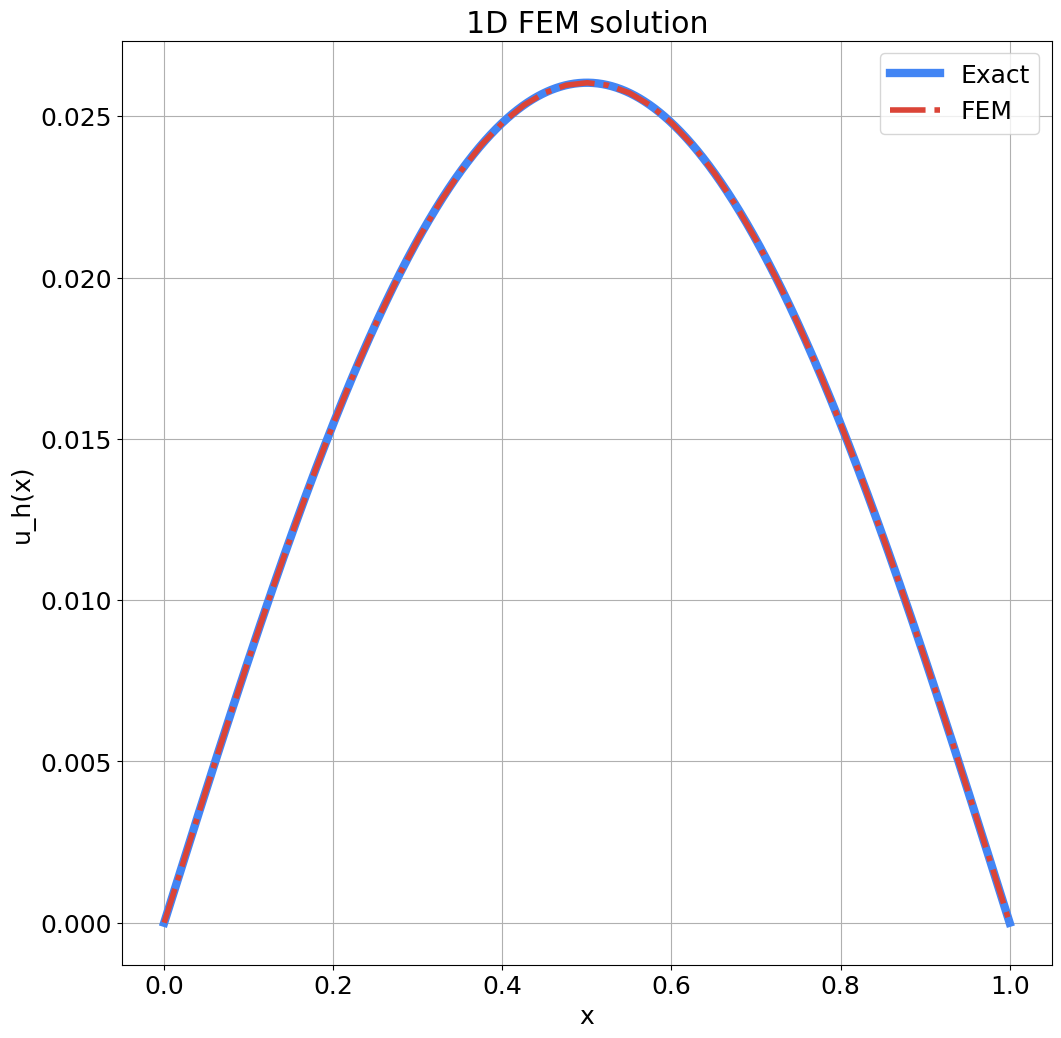

In [33]:
x_points = np.linspace(0, 1, 2000)
solution_np = np.array([solution_gf(xi) for xi in x_points])
exact_np = np.array([exact(xi) for xi in x_points])

plt.rcParams.update({'font.size': 18})

plt.plot(x_points, exact_np, linewidth=6, color='#4285F4', label="Exact")
plt.plot(x_points, solution_np, linewidth=4, linestyle='-.', color='#DB4437', label="FEM")
plt.xlabel("x")
plt.ylabel("u_h(x)")
plt.title("1D FEM solution")
plt.grid()
plt.legend()
plt.legend(frameon=True)
plt.show()

In [34]:
exact_cf = x*(x - 1)*(x*x - x - 1)/12

error_L2 = sqrt(Integrate((solution_gf - exact_cf)**2, mesh))
print ("L2 norm error:", error_L2)

L2 norm error: 1.0415266415743632e-05


In [35]:
exact_grad_cf = exact_cf.Diff(x)
error_H1_semi = sqrt(Integrate((grad(solution_gf) - exact_grad_cf)**2, mesh))
print ("H1 seminorm error:", error_H1_semi)


H1 seminorm error: 0.0013174785702189272


In [36]:
error_H1 = sqrt(error_L2**2 + error_H1_semi**2)
print ("H1 norm error:", error_H1)

H1 norm error: 0.001317519738281222
